# IMDB Movies — Data Science Project

**Business Problem:**
- Can we predict a movie's rating or revenue based on features like genre, duration, budget, etc.?
- Can we classify movies as **hit** or **flop** (e.g., based on rating threshold)?

**Objectives:**
1. Clean and preprocess data  
2. Exploratory Data Analysis (EDA)  
3. Build predictive models (Linear & Logistic Regression)  
4. Prepare data for Power BI / Tableau dashboards

## 1. Load & Inspect Dataset

In [1]:
import numpy as np
import pandas as pd

# Load dataset (use the CSV in this folder)
df = pd.read_csv("imdb_movies.csv")
df.head()

,movie_id,title,year,certificate,runtime_minutes,genre,rating,metascore,description,director,stars,votes,gross_millions
0,tt1000835,Dark Love 728,2004,PG-13,103,"Action, Musical",9.5,NaN,A critically acclaimed action masterpiece.,Park Chan-wook,"Matt Damon, Leonardo DiCaprio, Meryl Streep, R...",774648,204.79
1,tt1000768,First Awakening 661,2012,R,159,"War, Animation",9.5,NaN,An epic war tale directed by Ridley Scott.,Ridley Scott,"Matt Damon, Jack Nicholson, Chris Hemsworth, Z...",297518,951.58
2,tt1000652,The Dreams 545,2008,R,77,"Action, Mystery, War",9.5,100.0,An epic action tale directed by Spike Lee.,Spike Lee,"Natalie Portman, Mark Ruffalo, Viola Davis, Ha...",583752,372.85
3,tt1000538,Last Mission 431,2019,PG-13,116,Biography,9.5,NaN,A critically acclaimed biography masterpiece.,Jordan Peele,"Al Pacino, Gary Oldman, Keanu Reeves, Kate Win...",187450,NaN
4,tt1000159,The Story 52,2000,R,126,Mystery,9.5,99.0,A mystery film set in 2000.,Park Chan-wook,"Zendaya, Chris Hemsworth, Viola Davis, Mark Ru...",642106,252.83


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         1000 non-null   object 
 1   title            1000 non-null   object 
 2   year             1000 non-null   int64  
 3   certificate      1000 non-null   object 
 4   runtime_minutes  1000 non-null   int64  
 5   genre            1000 non-null   object 
 6   rating           1000 non-null   float64
 7   metascore        645 non-null    float64
 8   description      1000 non-null   object 
 9   director         1000 non-null   object 
 10  stars            1000 non-null   object 
 11  votes            1000 non-null   int64  
 12  gross_millions   704 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 101.7+ KB


In [3]:
df.describe()

,year,runtime_minutes,rating,metascore,votes,gross_millions
count,1000.000000,1000.000000,1000.000000,645.000000,1.000000e+03,704.000000
mean,2005.950000,120.624000,6.944000,69.400000,1.859305e+05,259.792187
std,14.675519,19.318847,0.955896,12.412476,3.500846e+05,175.150193
min,1940.000000,70.000000,4.100000,30.000000,1.000000e+03,5.200000
25%,2001.000000,108.000000,6.300000,61.000000,2.423900e+04,127.750000
50%,2008.000000,121.000000,6.900000,70.000000,6.636300e+04,235.390000
75%,2016.000000,133.000000,7.600000,77.000000,1.758815e+05,370.452500
max,2024.000000,198.000000,9.500000,100.000000,2.500000e+06,987.170000


In [4]:
# Check common issues: missing values, duplicates
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
movie_id             0
title                0
year                 0
certificate          0
runtime_minutes      0
genre                0
rating               0
metascore          355
description          0
director             0
stars                0
votes                0
gross_millions     296
dtype: int64

Duplicate rows: 0


## 2. Data Preprocessing

### 2.1 Handle Missing Values

In [5]:
# Drop rows where target (rating) is missing; impute numeric columns
df = df.dropna(subset=["rating"])
# Impute metascore and gross_millions with median
df["metascore"] = df["metascore"].fillna(df["metascore"].median())
df["gross_millions"] = df["gross_millions"].fillna(df["gross_millions"].median())
# Drop any remaining rows with missing key features (optional safety)
df = df.dropna(subset=["year", "runtime_minutes", "genre"])
print("Missing after preprocessing:")
print(df.isnull().sum())

Missing after preprocessing:
movie_id           0
title              0
year               0
certificate        0
runtime_minutes    0
genre              0
rating             0
metascore          0
description        0
director           0
stars              0
votes              0
gross_millions     0
dtype: int64


### 2.2 Convert Data Types

In [6]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["runtime_minutes"] = pd.to_numeric(df["runtime_minutes"], errors="coerce")
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")
df = df.dropna(subset=["year", "runtime_minutes"])  # drop if conversion failed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         1000 non-null   object 
 1   title            1000 non-null   object 
 2   year             1000 non-null   int64  
 3   certificate      1000 non-null   object 
 4   runtime_minutes  1000 non-null   int64  
 5   genre            1000 non-null   object 
 6   rating           1000 non-null   float64
 7   metascore        1000 non-null   float64
 8   description      1000 non-null   object 
 9   director         1000 non-null   object 
 10  stars            1000 non-null   object 
 11  votes            1000 non-null   int64  
 12  gross_millions   1000 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 101.7+ KB


### 2.3 Feature Engineering

In [7]:
# Movie age (years since release)
df["movie_age"] = 2026 - df["year"]

# Genre count (number of genres if comma-separated)
df["genre_count"] = df["genre"].str.split(", ").str.len().fillna(1).astype(int)

# Binary target: hit (1) if rating >= 7.0, else flop (0)
df["hit"] = np.where(df["rating"] >= 7.0, 1, 0)
print("Hit vs Flop counts:")
print(df["hit"].value_counts())

Hit vs Flop counts:
hit
0    506
1    494
Name: count, dtype: int64


### 2.4 Encode Categorical Fields

Encode `genre` and `certificate` for modeling. Drop text/ID columns that are not features.

In [8]:
# Keep a copy for EDA and export (with original columns)
df_eda = df.copy()

# For ML: drop columns we won't use as features
cols_to_drop = ["movie_id", "title", "description", "director", "stars"]
df_ml = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

# One-hot encode categoricals (drop_first to avoid multicollinearity)
df_ml = pd.get_dummies(df_ml, columns=["genre", "certificate"], drop_first=True)
print("Shape after encoding:", df_ml.shape)
df_ml.head(2)

Shape after encoding: (1000, 474)


,year,runtime_minutes,rating,metascore,votes,gross_millions,movie_age,genre_count,hit,"genre_Action, Adventure",...,"genre_Western, Mystery, Sci-Fi","genre_Western, Romance, Biography","genre_Western, Sci-Fi","genre_Western, Sci-Fi, Documentary","genre_Western, Thriller",certificate_NC-17,certificate_Not Rated,certificate_PG,certificate_PG-13,certificate_R
0,2004,103,9.5,70.0,774648,204.79,22,2,1,False,...,False,False,False,False,False,False,False,False,True,False
1,2012,159,9.5,70.0,297518,951.58,14,2,1,False,...,False,False,False,False,False,False,False,False,False,True


## 3. Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

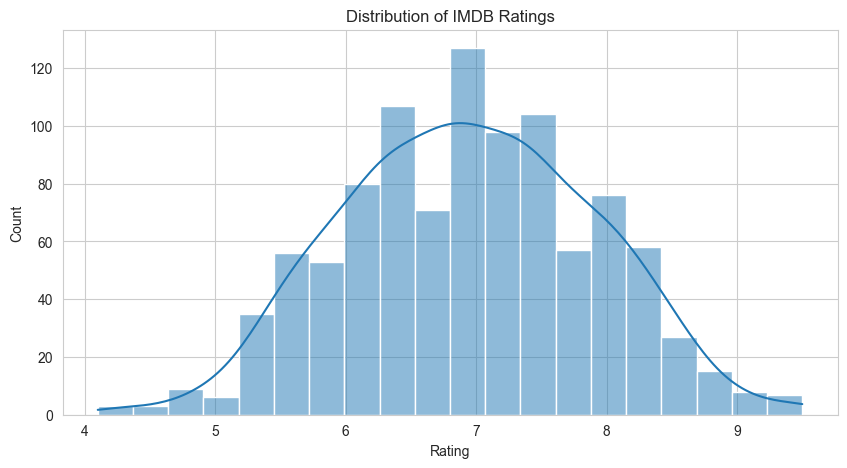

In [10]:
# Rating distribution
sns.histplot(df_eda["rating"], bins=20, kde=True)
plt.title("Distribution of IMDB Ratings")
plt.xlabel("Rating")
plt.show()

C:\Users\ankur\AppData\Local\Temp\ipykernel_3936\970862151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_rating, y="genre", x="mean", palette="viridis")


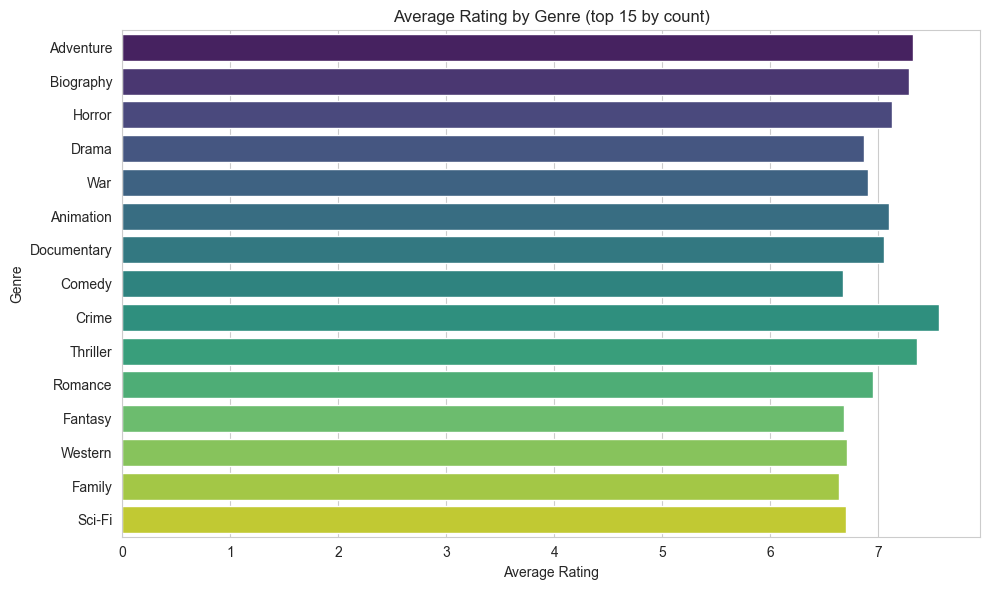

In [11]:
# Genre vs average rating (top genres by count)
genre_rating = df_eda.groupby("genre")["rating"].agg(["mean", "count"]).sort_values("count", ascending=False).head(15)
genre_rating = genre_rating.reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_rating, y="genre", x="mean", palette="viridis")
plt.title("Average Rating by Genre (top 15 by count)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

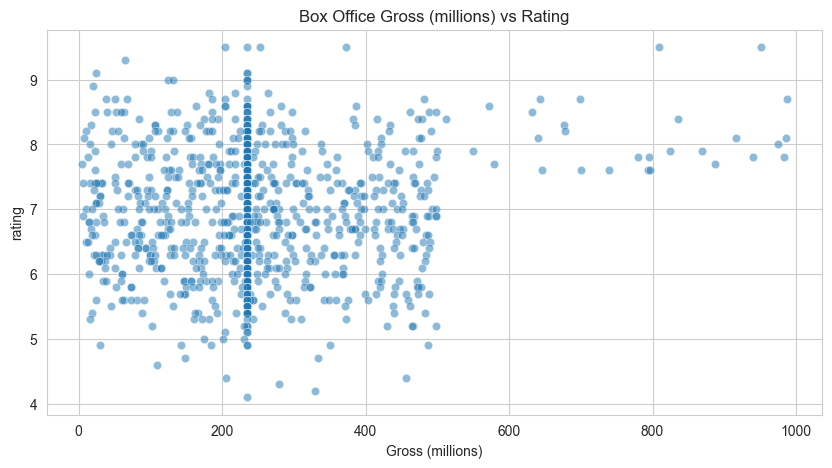

In [12]:
# Budget (gross) vs rating - scatter
sns.scatterplot(data=df_eda, x="gross_millions", y="rating", alpha=0.5)
plt.title("Box Office Gross (millions) vs Rating")
plt.xlabel("Gross (millions)")
plt.show()

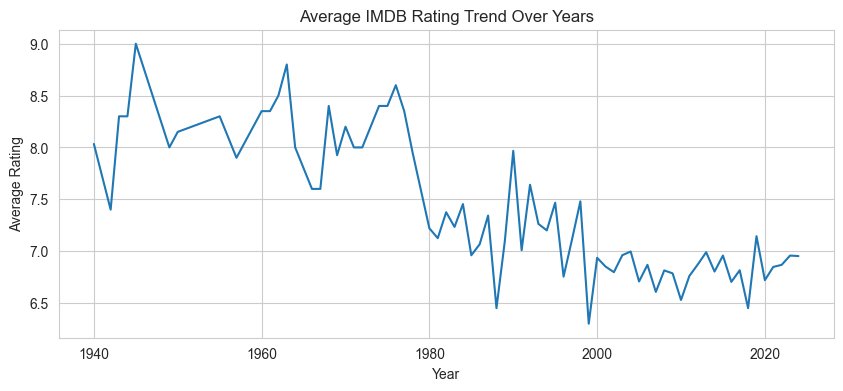

In [13]:
# Trend over years: average rating by year
year_rating = df_eda.groupby("year")["rating"].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=year_rating, x="year", y="rating")
plt.title("Average IMDB Rating Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

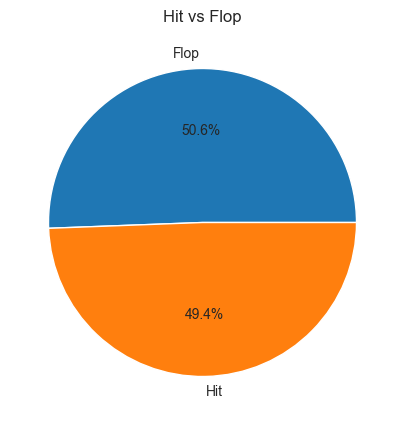

In [14]:
# Hit vs Flop counts (for dashboard)
df_eda["hit_label"] = df_eda["hit"].map({1: "Hit", 0: "Flop"})
vc = df_eda["hit_label"].value_counts()
vc.plot(kind="pie", autopct="%1.1f%%", labels=vc.index, title="Hit vs Flop")
plt.ylabel("")
plt.show()

## 4. Machine Learning Models

### 4.1 Linear Regression — Predict Rating

In [15]:
from sklearn.model_selection import train_test_split

# Features and target for regression (exclude hit to avoid leakage)
X_reg = df_ml.drop(columns=["rating", "hit"])
y_reg = df_ml["rating"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print("Train size:", len(X_train_r), "Test size:", len(X_test_r))

Train size: 800 Test size: 200


In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
from sklearn.metrics import mean_squared_error, r2_score

pred_r = lr.predict(X_test_r)
print("Linear Regression — Predict Rating")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_r)))
print("R2 Score:", r2_score(y_test_r, pred_r))

Linear Regression — Predict Rating
RMSE: 0.76873571936194
R2 Score: 0.3316497686347538


### 4.2 Logistic Regression — Classify Hit vs Flop

In [18]:
# Exclude rating (leakage) and hit (target)
X_clf = df_ml.drop(columns=["rating", "hit"])
y_clf = df_ml["hit"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)

c:\Users\ankur\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_c = log_reg.predict(X_test_c)
print("Logistic Regression — Hit vs Flop")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c, target_names=["Flop", "Hit"]))

Logistic Regression — Hit vs Flop
Accuracy: 0.66
              precision    recall  f1-score   support

        Flop       0.69      0.64      0.67       106
         Hit       0.63      0.68      0.65        94

    accuracy                           0.66       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.66      0.66      0.66       200



### 4.3 Model Interpretation — Which Factors Influence Rating?

(Using regression coefficients; for classification, similar interpretation can be done with logistic coefficients.)
Linear regression was used to model continuous outcomes such as rating and gross revenue, while logistic regression was used to classify movies into hit and flop categories based on a threshold rating. This combination allowed both predictive and decision-based insights.

In [21]:
# Top positive and negative drivers of rating (linear regression)
coef = pd.DataFrame({"feature": X_reg.columns, "coefficient": lr.coef_})
coef["abs_coef"] = np.abs(coef["coefficient"])
coef = coef.sort_values("abs_coef", ascending=False)
print("Top 10 features by impact on rating (absolute coefficient):")
print(coef.head(10).to_string(index=False))

Top 10 features by impact on rating (absolute coefficient):
                          feature  coefficient  abs_coef
            genre_Action, Musical     2.374593  2.374593
genre_Documentary, Drama, Fantasy    -2.336835  2.336835
    genre_Action, Sci-Fi, Mystery    -2.100900  2.100900
    genre_Sci-Fi, Comedy, Mystery    -1.864786  1.864786
     genre_Animation, Documentary    -1.810849  1.810849
       genre_Documentary, Romance     1.692384  1.692384
                genre_War, Action    -1.459549  1.459549
           genre_Mystery, Fantasy    -1.438436  1.438436
genre_Fantasy, Adventure, Mystery    -1.434910  1.434910
              genre_Drama, Comedy     1.426566  1.426566


## 5. Export Cleaned Data for Power BI / Tableau

In [22]:
# Save preprocessed data (with original columns + hit label for dashboards)
df_eda.to_csv("IMDB_cleaned.csv", index=False)
print("Saved IMDB_cleaned.csv for Power BI / Tableau")

Saved IMDB_cleaned.csv for Power BI / Tableau


## 6. Insights & Summary

**Recommended dashboard visuals (Power BI / Tableau):**

| Insight | Chart Type |
|--------|------------|
| Rating trend over years | Line Chart |
| Genre vs Avg Rating | Bar Chart |
| Hit vs Flop counts | Pie / Donut Chart |
| Genre & Certificate | Heatmap or grouped bar |
| Predictions vs Actual | Scatter Plot |

**Conclusions:** Run the notebook and use EDA plots + model metrics (RMSE, R², Accuracy, Classification Report) to summarize which factors influence rating, which genres tend to perform better, and whether runtime/votes/gross affect reviews.

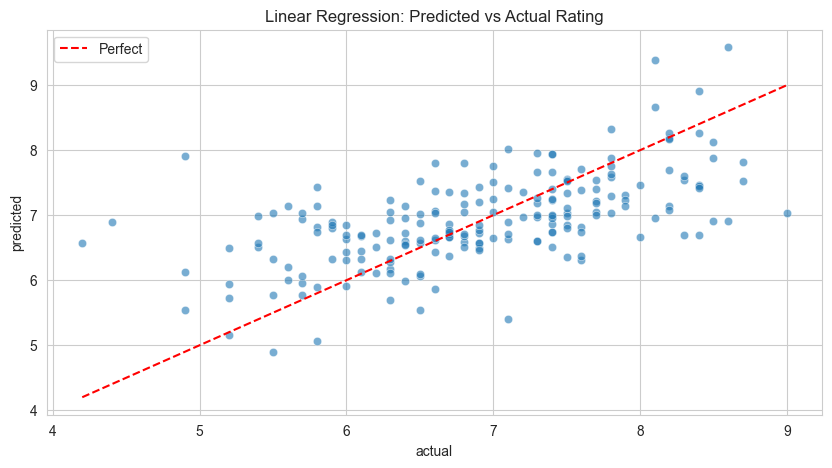

In [23]:
# Optional: Scatter — Model predictions vs actual (for dashboard export)
pred_df = pd.DataFrame({"actual": y_test_r, "predicted": pred_r})
sns.scatterplot(data=pred_df, x="actual", y="predicted", alpha=0.6)
plt.plot([pred_df["actual"].min(), pred_df["actual"].max()], [pred_df["actual"].min(), pred_df["actual"].max()], "r--", label="Perfect")
plt.title("Linear Regression: Predicted vs Actual Rating")
plt.legend()
plt.show()